# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs


**Disciplina:** Mineração de Dados  
**Grupo:** 1

Caio Cordeiro Fabri - 2023027939

Carolina Penido Barcellos - 2024024054

Isadora Silva Drumond - 2024074485

Letícia Ribeiro Miranda - 2021095686

**Dataset:** Spotify Tracks Dataset

**Tarefa de mineração:** Agrupamento

**Data da entrega:** 31/05/2026

---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | Spotify Tracks Dataset |
| Link público do dataset | https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset |
| Número de linhas | 114 001 |
| Número de colunas | 21 |
| Tarefa de mineração | Agrupamento |
| Diretriz 1 de IA responsável | Monitoramento e Avaliação |
| Diretriz 2 de IA responsável | Explicabilidade |
| LLM usada na Fase 2 — baseline | Gemini Pro |
| LLM usada na Fase 2 — guiada | Gemini Pro |
| Notebook da Fase 2 | https://github.com/carolinabarcellos/TP-2-Mineracao/blob/7aa8bfd4d987dae53f305c6a16e39f346ec20519/TP2_Fase2_Grupo1.ipynb |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Definição do problema como uma tarefa de clusterização não supervisionada | Grupo | Sim | O objetivo do projeto foi estruturado para identificar padrões de similaridade entre músicas utilizando atributos acústicos do dataset Spotify Tracks. |
| Uso de atributos acústicos como principais variáveis de análise | Baseline | Sim | Variáveis como danceability, energy, acousticness e valence foram consideradas adequadas para representar características musicais relevantes. |
| Hipótese inicial relacionando popularidade e padrões sonoros | Baseline | Parcialmente | A hipótese foi considerada inicialmente, mas deixou de ser o foco principal após discussão sobre possíveis vieses interpretativos. |
| Reformulação do foco do projeto para agrupar as músicas apenas por perfis sonoros | Guiada | Sim | A análise passou a priorizar agrupamentos associados a características musicais intrínsecas, como músicas energéticas, acústicas ou calmas. Evitou vieses ao relacionar popularidade diretamente a atributos acústicos. |
| Remoção de duplicatas no dataset | Baseline | Sim | A limpeza dos dados foi necessária para evitar redundâncias que poderiam distorcer os agrupamentos. |
| Tratamento de outliers na variável `duration_ms` | Baseline | Sim | Valores extremos foram removidos para reduzir impacto desproporcional sobre algoritmos baseados em distância. |
| Normalização dos atributos numéricos | Baseline e Guiada | Sim | A padronização foi aplicada para evitar que variáveis em escalas maiores dominassem o processo de clusterização. |
| Seleção apenas de atributos numéricos relevantes | Baseline e Guiada  | Sim | Variáveis textuais e identificadores foram excluídos para manter coerência com os algoritmos utilizados. |
| Teste de múltiplos algoritmos de clusterização | Grupo | Sim | Diferentes abordagens foram avaliadas para comparar estabilidade e qualidade dos agrupamentos, utilizando todos os algoritmos que julgamos adequados (DBSCAN, K-Means, GMM e Clustering Hierárquico) |
| Uso do método do cotovelo para escolha do número de clusters | Baseline | Sim | O método foi utilizado como apoio inicial na definição de valores plausíveis para K. |
| Uso de métricas quantitativas de avaliação | Baseline e Guiada | Sim | Métricas como Silhouette Score e Davies-Bouldin foram adotadas para validar coesão e separação dos clusters. |
| Uso de PCA ou UMAP para visualização dos agrupamentos | Baseline e Guiada | Não | O PCA e o UMAP foram testados na fase 2, mas apresentaram  forte sobreposição visual devido à alta dimensionalidade dos dados. Não serão mantidos na fase 3.|
| Abandono da dependência de visualização bidimensional | Grupo | Sim | A validação passou a concentrar-se em métricas quantitativas e interpretação qualitativa dos grupos. |
| Inclusão de auditoria humana dos clusters | Guiada | Sim | Os agrupamentos foram interpretados semanticamente para verificar coerência musical além dos indicadores matemáticos. |
| Descrição semântica dos clusters obtidos | Grupo | Sim | Cada agrupamento passou a ser analisado segundo características predominantes, como energia, instrumentalidade ou acústica. |
| Comparação entre diferentes estratégias de validação | Grupo | Sim | Foram combinadas avaliações quantitativas e qualitativas para aumentar robustez e interpretabilidade dos resultados. |
| Análise sistemática de estabilidade entre diferentes sementes aleatórias | Grupo | Sim | Verificar se pequenas mudanças na inicialização produzem agrupamentos muito diferentes ou praticamente iguais. | 

> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [10]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Substitua pelo caminho real do arquivo usado pelo grupo.
DATA_PATH = "dados/dataset.csv"

# Tipo de tarefa do TP.
# Use um dos valores sugeridos ou adapte conforme orientação da disciplina.
# Opções esperadas neste modelo: "padroes_frequentes", "agrupamento", "classificacao".
TASK_TYPE = "agrupamento"

# Coluna-alvo, quando aplicável.
# Para classificação, deve indicar a variável de classe.
# Para clustering ou padrões frequentes, normalmente será None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna usada para gerar transações, quando o TP for de padrões frequentes.
TRANSACTION_COLUMN = "[INSERIR_COLUNA_DE_TRANSACOES]"

# Diretório opcional para salvar tabelas, figuras ou artefatos.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")

Configuração inicial carregada.
TASK_TYPE = agrupamento
DATA_PATH = dados/dataset.csv


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

Dado um conjunto de dados composto por músicas do Spotify e seus respectivos atributos, o objetivo deste trabalho é aplicar técnicas de mineração de dados para agrupá-las estritamente com base em suas características sonoras, formando conjuntos de faixas com perfis acústicos semelhantes.

### Estrutura do problema

- **Contexto:**  
O crescimento das plataformas de streaming musical gerou grandes volumes de dados relacionados às características sonoras das músicas. Esses dados possuem variáveis numéricas perfeitamente apropriadas para a aplicação de algoritmos clássicos de clusterização, o que permite explorar conceitos fundamentais de mineração de dados. O projeto utilizará o Spotify Tracks Dataset, uma base disponível no Kaggle com 114.001 registros, para analisar atributos acústicos essenciais, como danceability, energy, valence, acousticness e o próprio gênero musical.

- **Problema:**  
Apesar da existência de gêneros musicais previamente definidos, faixas de gêneros distintos podem apresentar características acústicas muito semelhantes, o que frequentemente dificulta a interpretação das categorias musicais e dos padrões de consumo. Dessa forma, surge a necessidade de descobrir agrupamentos naturais entre as músicas, partindo da hipótese de que elas podem ser agrupadas em perfis sonoros semelhantes de maneira independente do gênero previamente informado.  

- **Objetivo analítico:**  
O objetivo principal é aplicar técnicas de agrupamento não supervisionado (como K-Means, Hierarchical Clustering e DBSCAN) sobre as músicas do Spotify para identificar padrões de similaridade e gerar clusters a partir de atributos acústicos e comportamentais. Busca-se identificar grupos bem definidos associados a músicas dançantes, acústicas, energéticas ou calmas. 

- **Usuários ou interessados:**  
Os resultados beneficiam diretamente os desenvolvedores e gestores de plataformas digitais focados na organização automática de playlists, sistemas de recomendação musical e segmentação de conteúdos.

- **Decisões apoiadas:**  
A análise oferece suporte prático para a organização automatizada e coerente de playlists baseadas em perfis sonoros. Ela também auxilia na tomada de decisões estratégicas ao identificar como diferentes padrões de atributos musicais influenciam a formação de perfis sonoros e a sua respectiva popularidade na plataforma. Por fim, as conclusões apoiarão decisões metodológicas futuras em projetos de dados, demonstrando as vantagens e limitações geradas pelo uso de LLMs na escolha de algoritmos e métricas de avaliação.

### Ajustes em relação à Fase 2

Durante a interação com as LLMs, o problema inicial foi refinado. Inicialmente, o projeto também buscava investigar relações entre popularidade musical e atributos acústicos. Entretanto, observou-se que utilizar popularidade como variável central poderia introduzir vieses interpretativos, desviando o foco da análise de similaridade sonora. Assim, o objetivo foi reformulado para concentrar-se exclusivamente na descoberta de agrupamentos baseados em características acústicas intrínsecas das músicas.

A preparacao dos dados ficou bem clara desde o comeco e tudo o que foi feito na Fase 2 será mantido.

A estratégia de modelagem também passou por ajustes importantes. Inicialmente, pretendia-se definir o número de clusters do K-Means utilizando o método do cotovelo (*Elbow Method*). Contudo, os resultados obtidos levaram para um valor muito alto de \(k\). Dessa forma, a escolha do número de clusters passou a considerar métricas quantitativas adicionais, como *Silhouette Score* e *Davies-Bouldin Index*, executando o algoritmo para diferentes valores de \(k\) e comparando a qualidade dos agrupamentos gerados.

Além disso, também foi testada na Fase 2 a clusterização hierárquica como alternativa complementar ao K-Means. Entretanto, devido ao alto custo computacional do método, cuja complexidade pode chegar a \(O(n^3)\), o algoritmo precisou ser executado apenas sobre uma amostra reduzida do dataset. Mesmo assim, os resultados obtidos apresentaram pouca interpretabilidade prática dos agrupamentos.

Esses experimentos evidenciaram um trade-off entre desempenho computacional, escalabilidade e interpretabilidade. Embora métodos hierárquicos possam oferecer representações estruturais interessantes em bases menores, o K-Means mostrou-se mais viável para o volume de dados utilizado no projeto.

Por fim, tentativas de validação visual utilizando PCA e UMAP mostraram-se limitadas devido à elevada sobreposição entre os dados em baixa dimensionalidade. Como consequência, a avaliação dos clusters passou a priorizar métricas quantitativas, complementadas por auditoria humana e interpretação semântica dos agrupamentos gerados.


## 1.1 Problema de negócio e objetivo analítico

Dado um conjunto de dados composto por músicas do Spotify e seus respectivos atributos acústicos e comportamentais, o objetivo deste trabalho é aplicar técnicas de mineração de dados para agrupar faixas musicais estritamente com base em suas características sonoras, formando conjuntos de músicas com perfis acústicos semelhantes.

### Estrutura do problema

- **Contexto:**  
O crescimento das plataformas de streaming musical gerou grandes volumes de dados relacionados às características acústicas das músicas. Esses dados incluem atributos numéricos extraídos automaticamente, como *danceability*, *energy*, *valence*, *acousticness* e *tempo*, permitindo representar matematicamente diferentes aspectos musicais. Nesse contexto, técnicas clássicas de clusterização tornam-se apropriadas para identificar padrões de similaridade entre faixas musicais. O projeto utiliza o Spotify Tracks Dataset, disponível no Kaggle, contendo aproximadamente 114 mil músicas e múltiplos atributos acústicos, estruturais e comportamentais.

- **Problema:**  
Embora existam gêneros musicais previamente definidos, músicas pertencentes a gêneros diferentes podem compartilhar características sonoras muito semelhantes. Isso limita a capacidade de representar adequadamente perfis musicais apenas com base em rótulos categóricos tradicionais. Dessa forma, surge a necessidade de identificar agrupamentos naturais entre músicas a partir de seus atributos acústicos, investigando se é possível formar clusters semanticamente coerentes independentemente do gênero informado originalmente.

- **Objetivo analítico:**  
O objetivo principal é aplicar técnicas de agrupamento não supervisionado, como K-Means, Hierarchical Clustering e DBSCAN, para identificar padrões de similaridade sonora entre músicas do Spotify. Busca-se descobrir agrupamentos associados a perfis acústicos específicos, como músicas dançantes, energéticas, acústicas, instrumentais ou calmas, avaliando quantitativamente a qualidade e a separação dos clusters obtidos.

- **Usuários ou interessados:**  
Os resultados podem beneficiar plataformas de streaming musical, sistemas de recomendação, desenvolvedores de aplicações musicais, pesquisadores em mineração de dados e profissionais interessados em organização automática de conteúdo musical.

- **Decisões apoiadas:**  
A análise pode apoiar a criação automática de playlists, recomendação de músicas similares, segmentação de catálogos musicais e identificação de perfis sonoros predominantes. Além disso, os resultados auxiliam na compreensão das vantagens e limitações de diferentes algoritmos de clusterização aplicados a dados musicais de alta dimensionalidade.

### Ajustes em relação à Fase 2

Durante a interação com as LLMs, o problema inicialmente proposto passou por refinamentos importantes. Em um primeiro momento, o projeto também buscava investigar possíveis relações entre popularidade musical e atributos acústicos. Entretanto, observou-se que utilizar popularidade como variável central poderia introduzir vieses interpretativos, desviando o foco da análise de similaridade sonora. Dessa forma, optou-se por reformular o objetivo do trabalho, concentrando a análise exclusivamente na descoberta de agrupamentos baseados em características acústicas intrínsecas das músicas.

A etapa de preparação dos dados permaneceu praticamente inalterada em relação à Fase 2. Foram mantidos os procedimentos previamente definidos de limpeza, normalização, remoção de duplicatas e tratamento de outliers, considerados adequados para garantir consistência e estabilidade aos algoritmos de clusterização. Além disso, as variáveis `track_id` e `popularity` serão removidas da modelagem: `track_id` por atuar apenas como identificador técnico sem relevância analítica, e `popularity` para evitar vieses relacionados ao sucesso comercial das músicas, mantendo o foco exclusivamente nas características acústicas.

A estratégia de modelagem também passou por ajustes relevantes. Inicialmente, pretendia-se definir o número de clusters do algoritmo K-Means utilizando apenas o método do cotovelo (*Elbow Method*). Contudo, os resultados obtidos indicaram valores muito elevados de \(k\), dificultando a interpretação prática e semântica dos agrupamentos. Assim, a definição do número de clusters passou a considerar métricas quantitativas complementares, como *Silhouette Score* e *Davies-Bouldin Index*, executando o algoritmo para diferentes valores de \(k\) e comparando objetivamente a qualidade dos agrupamentos gerados.

Além disso, a clusterização hierárquica também foi avaliada como alternativa complementar ao K-Means. Entretanto, devido ao alto custo computacional do método, cuja complexidade pode chegar a O(n³), o algoritmo precisou ser executado apenas sobre uma amostra reduzida do dataset. Mesmo nesse cenário reduzido, os agrupamentos obtidos apresentaram baixa interpretabilidade prática e pouca separação visual relevante. Esses resultados evidenciaram um importante trade-off entre desempenho computacional, escalabilidade e interpretabilidade dos modelos. Na Fase 3, pretende-se investigar estratégias que possam minimizar essas limitações sem comprometer a qualidade dos agrupamentos.

A decisão de comparar diferentes algoritmos de clusterização será mantida na Fase 3, pois consideramos importante avaliar abordagens distintas antes da definição final do modelo mais adequado. Ainda assim, os experimentos realizados até o momento indicaram que o K-Means apresentou melhor equilíbrio entre desempenho computacional, escalabilidade e qualidade dos agrupamentos, tornando-se a principal abordagem priorizada nas próximas etapas do projeto.

Por fim, tentativas de validação visual utilizando PCA e UMAP mostraram-se limitadas devido à elevada sobreposição dos dados após a redução para duas dimensões. Mesmo utilizando diferentes técnicas de projeção, os clusters permaneceram visualmente pouco separados, dificultando interpretações confiáveis apenas pela inspeção gráfica. Como consequência, a avaliação dos agrupamentos passou a priorizar métricas quantitativas, complementadas por auditoria humana e interpretação semântica dos clusters gerados, o que pretendemos ampliar na Fase 3.

Além disso, o nosso grupo fixou `RANDOM_STATE=42` em todos os modelos para garantir reprodutibilidade dos experimentos realizados. Entretanto, não foi conduzida uma análise sistemática de estabilidade entre diferentes sementes aleatórias, o que representa uma limitação metodológica importante a ser explorada e corrigida na Fase 3.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** Spotify Tracks Dataset
- **Fonte:** Kaggle
- **Link público:** https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset 
- **Data de acesso ou download:** 15/05/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | Cada linha representa uma faixa musical individual disponível no Spotify, contendo atributos acústicos, comportamentais e metadados associados à música. | |
| O que cada coluna representa? | Cada coluna descreve uma característica da faixa, incluindo informações textuais (nome da música, artista e álbum), atributos acústicos (danceability, energy, valence, acousticness etc.), informações estruturais (tempo, duração, compasso) e dados de popularidade. | |
| Número de instâncias | 114 001 mil músicas. |
| Número de atributos | 21 |
| Tipos principais de atributos | Numéricos e categóricos |
| Existe variável-alvo? | NÃO. O projeto utiliza aprendizado não supervisionado, portanto não há variável-alvo definida previamente. |
| Existem atributos sensíveis ou identificadores? | Sim. O atributo `track_id` funciona como identificador único da música, e atributos textuais como `artists`, `album_name` e `track_name` também podem ser utilizados para identificação das músicas e para a interpretação qualitativa dos agrupamentos. Todavia, esses atributos identificadores, não representam dados pessoais sensíveis. |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| `track_id` | String | Identificador único da música no Spotify | REMOVIDA | Apenas um identificador técnico; não contribui para a formação dos agrupamentos. |
| `artists` | String | Nome do(s) artista(s) da faixa | ID | Utilizado apenas para interpretação qualitativa e análise semântica dos clusters. |
| `album_name` | String | Nome do álbum ao qual a música pertence | ID | Auxilia na exploração manual e contextualização dos agrupamentos encontrados. |
| `track_name` | String | Nome da faixa musical | ID | Empregado na interpretação qualitativa dos resultados obtidos. |
| `popularity` | Numérico | Índice de popularidade da música no Spotify (0–100) | REMOVIDA | Removida para evitar viés na clusterização, já que o foco do projeto é agrupar músicas por características acústicas e não por sucesso comercial. |
| `duration_ms` | Numérico | Duração da música em milissegundos | FEATURE | Permite avaliar se a duração influencia a formação de perfis musicais semelhantes. |
| `explicit` | Booleano | Indica presença de conteúdo explícito | FEATURE | Possibilita investigar se músicas explícitas tendem a formar agrupamentos específicos. |
| `danceability` | Numérico (0.0–1.0) | Grau de adequação da música para dança | FEATURE | Um dos principais atributos acústicos do estudo; importante para caracterizar ritmo e potencial dançante. |
| `energy` | Numérico (0.0–1.0) | Intensidade e atividade percebida da música | FEATURE | Essencial para distinguir músicas mais intensas e agitadas de faixas mais suaves e calmas. |
| `key` | Inteiro | Tom musical da faixa | FEATURE | Variável complementar para identificação de padrões harmônicos semelhantes entre músicas. |
| `loudness` | Numérico | Volume geral da faixa em decibéis (dB) | FEATURE | Complementa a percepção de intensidade sonora e auxilia na diferenciação entre perfis musicais. |
| `mode` | Inteiro | Modalidade musical: maior (1) ou menor (0) | FEATURE | Relacionado à estrutura melódica e ao aspecto harmônico das músicas. |
| `speechiness` | Numérico (0.0–1.0) | Presença estimada de fala na faixa | FEATURE | Importante para identificar músicas com predominância vocal ou falada, como rap e podcasts. |
| `acousticness` | Numérico (0.0–1.0) | Probabilidade da música ser acústica | FEATURE | Fundamental para distinguir músicas acústicas de produções fortemente digitais ou eletrônicas. |
| `instrumentalness` | Numérico (0.0–1.0) | Probabilidade da faixa não possuir vocais | FEATURE | Auxilia na identificação de músicas predominantemente instrumentais. |
| `liveness` | Numérico | Probabilidade da gravação ter sido realizada ao vivo | FEATURE | Permite analisar diferenças entre gravações de estúdio e apresentações ao vivo. |
| `valence` | Numérico (0.0–1.0) | Medida de positividade emocional transmitida pela música | FEATURE | Relevante para diferenciar músicas alegres/eufóricas de faixas melancólicas ou introspectivas. |
| `tempo` | Numérico | Velocidade estimada da música em BPM | FEATURE | Caracteriza o ritmo e a velocidade estrutural das músicas. |
| `time_signature` | Numérico | Compasso estimado da música | FEATURE | Utilizado para análise complementar da estrutura rítmica das faixas. |
| `track_genre` | Categórica | Gênero musical atribuído à faixa | FEATURE | Utilizado principalmente na análise pós-processamento para comparar os clusters encontrados com gêneros previamente definidos. |

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Monitoramento e Avaliação | Em problemas de clusterização, não existe uma resposta correta previamente conhecida. Assim, torna-se fundamental avaliar a qualidade dos agrupamentos para verificar se os clusters representam padrões musicais consistentes e não apenas separações artificiais produzidas pelo algoritmo. | Essa diretriz influenciou diretamente as etapas de modelagem e validação. O projeto passou a enfatizar a comparação sistemática entre diferentes algoritmos e o uso de métricas quantitativas de avaliação interna dos clusters, além de análises qualitativas conduzidas manualmente. Também motivou a realização de testes com diferentes configurações de parâmetros. | Uso de métricas como Silhouette Score e Davies-Bouldin Index; execução do K-Means para múltiplos valores de k; comparação entre K-Means, DBSCAN e clusterização hierárquica; auditoria humana dos agrupamentos obtidos. |
| Explicabilidade | A clusterização pode gerar grupos difíceis de interpretar. Assim, é importante compreender quais atributos caracterizam cada cluster e como esses padrões se relacionam com perfis musicais reais.| Essa diretriz influenciou tanto a seleção das variáveis quanto a interpretação dos resultados. O grupo priorizou atributos acústicos semanticamente relevantes e buscou utilizar métodos mais interpretáveis, permitindo descrever de forma clara as características predominantes de cada agrupamento. Além disso, foram evitadas variáveis potencialmente enviesadas ou pouco relacionadas à similaridade sonora. | Remoção da variável popularity; análise das médias dos atributos acústicos por cluster; interpretação semântica dos grupos (músicas mais energéticas, acústicas, dançantes etc.); priorização do K-Means devido à maior interpretabilidade prática dos centroides. |

### Análise

As diretrizes de IA responsável influenciaram diretamente decisões importantes de preparação dos dados, modelagem e avaliação do projeto.

No contexto da explicabilidade, a principal mudança ocorreu ainda na etapa de preparação dos dados, com a remoção da variável popularity. Essa variável foi considerada inadequada para um problema cujo objetivo era identificar similaridade sonora entre músicas, e não sucesso comercial. Sua exclusão evitou que os agrupamentos fossem influenciados pela popularidade dos artistas ou faixas, tornando a análise mais coerente com a proposta de aprendizado não supervisionado. Além disso, a diretriz de explicabilidade também incentivou a interpretação semântica dos clusters a partir de atributos acústicos como energy, danceability, valence e acousticness, permitindo compreender quais características definiam cada agrupamento. Além disso, foi proposta uma auditoria humana dos clusters.

Já a diretriz de monitoramento e avaliação influenciou principalmente a etapa de modelagem. Em vez de utilizar apenas um algoritmo ou confiar exclusivamente em visualizações, o projeto passou a comparar diferentes abordagens de clusterização, como K-Means, DBSCAN e agrupamento hierárquico. Também foram utilizadas métricas quantitativas, como Silhouette Score e Davies-Bouldin Index, para avaliar a qualidade dos clusters obtidos. Essa diretriz incentivou uma análise mais crítica e sistemática dos resultados, reduzindo o risco de interpretações superficiais ou agrupamentos matematicamente inconsistentes.

De forma geral, ambas as diretrizes mostraram-se altamente aplicáveis ao problema, especialmente porque tarefas de clusterização dependem fortemente de validação qualitativa e interpretação humana dos agrupamentos encontrados. Enquanto a explicabilidade contribuiu para tornar os resultados compreensíveis e semanticamente úteis, o monitoramento e avaliação garantiu maior rigor na validação dos modelos e na comparação entre diferentes soluções.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [3]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

if DATA_PATH == "[INSERIR_CAMINHO_DO_ARQUIVO]":
    print("ATENÇÃO: substitua DATA_PATH pelo caminho real do dataset antes de executar o notebook.")
    df = None
else:
    # Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
    df = pd.read_csv(DATA_PATH)
    print("Dataset carregado com sucesso.")
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}")
    display(df.head())

Dataset carregado com sucesso.
Linhas: 114000
Colunas: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "Sim (Kaggle)",
            "atende": "True"
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,114000,True
1,Mínimo de 4 colunas,21,True
2,Dataset publicamente acessível,Sim (Kaggle),True


In [5]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
Unnamed: 0,int64,0,0.0,114000,0
track_id,str,0,0.0,89741,5SuOikwiRyPMVoIQDJUgSV
track_name,str,1,0.0,73608,Comedy
duration_ms,int64,0,0.0,50697,230666
album_name,str,1,0.0,46589,Comedy
tempo,float64,0,0.0,45653,87.917
artists,str,1,0.0,31437,Gen Hoshino
loudness,float64,0,0.0,19480,-6.746
instrumentalness,float64,0,0.0,5346,0.000001
acousticness,float64,0,0.0,5061,0.0322


## 2.1 Interpretação da exploração inicial

A exploração inicial confirmou a estrutura robusta do Spotify Tracks Dataset, que possui 114.000 linhas e 21 colunas. As principais observações sobre os dados são:
- **Tipos de variáveis:** A base mescla atributos textuais (como track_id, track_name e artists), variáveis booleanas (explicit), atributos numéricos inteiros (duration_ms, key, mode, time_signature, popularity) e variáveis numéricas contínuas (como danceability, energy, acousticness e valence);
- **Valores ausentes:** A análise mostrou que a base de dados tem uma qualidade excelent. Existem apenas 3 registros nulos em toda a base: 1 na coluna track_name, 1 em album_name e 1 em artists. Todos os atributos estão 100% preenchidos (só obtivemos 0,0% percntuais de nulos);
- **Duplicatas:** A tabela demonstrou que, apesar de termos 114.000 linhas, a coluna track_id possui apenas 89.741 valores únicos. Isso mostra que existem mais de 24.000 repetições de músicas na base, o que ocorre porque a mesma faixa (mesmo ID) pode estar associada a diferentes rótulos na coluna track_genre.
- **Colunas com alta cardinalidade:**  As colunas de texto possuem cardinalidade muito alta, como esperado para uma base do Spotify. Destacam-se as colunas track_name (73.608 valores únicos), album_name (46.589 valores únicos) e artists (31.437 valores únicos);
- **Possíveis identificadores:** A coluna principal de identificação é a track_id. A tabela também revelou uma coluna chamada Unnamed: 0, que é um índice numérico residual da exportação do CSV original e não tem utilidade analítica.;
- **Possíveis atributos sensíveis:** A coluna categórica explicit (booleana) é um atributo sensível por indicar a presença de conteúdo adulto. A variável popularity também pode enviesar a análise, pois agrupa músicas pelo atual sucesso comercial (viés de mercado) e não por sua similaridade sonora real;
- **Atributos relevantes para a tarefa:** Para os algoritmos de clusterização, o foco será nas variáveis numéricas de formato contínuo (float64) que medem as características acústicas e o perfil sonoro das faixas. Assim, os atributos relevantes serão: danceability, energy, cousticness, instrumentalness, valence, speechiness, loudness, tempo e liveness;
- **Limitações percebidas:** Observando os exemplos de valor na tabela, a principal limitação estrutural é a disparidade de escalas. Enquanto atributos como danceability (0.676), energy (0.461) e acousticness (0.0322) operam entre 0 e 1, a coluna tempo está em BPM (87.917) e loudness está em decibéis negativos (-6.746). Além disso, a manutenção da coluna Unnamed: 0 e das músicas duplicadas (pelo track_id) exigemuma limpeza inicial.

### Relação com decisões da Fase 2

A exploração dos dados confirmou os principais alertas e sugestões apontados pela LLM na interação guiada (Trilha B) e mapeados na proposta inicial do projeto:
- *Necessidade Obrigatória de Normalização:* A LLM alertou que a diferença de escalas numéricas dominaria o cálculo de distâncias nos algoritmos de agrupamento. A exploração confirmou essa limitação de forma matemática: atributos como danceability (ex: 0.676) e acousticness (ex: 0.0322) operam em uma escala de 0 a 1, enquanto a variável tempo apresenta valores muito maiores em batidas por minuto (ex: 87.917) e loudness varia em decibéis negativos. Assim, a decisão de padronizar e normalizar as variáveis numéricas antes da aplicação dos algoritmos torna-se uma etapa necessária;
- *Remoção de Duplicatas e Colunas Residuai:* O projeto já previa como restrição o risco de a base conter ruídos e músicas duplicadas. A análise da cardinalidade comprovou isso: apesar de existirem 114.000 registros, a coluna track_id possui apenas 89.741 valores únicos, indicando mais de 24.000 músicas repetidas na base. Portanto, a decisão de limpeza na Fase 2 incluirá a remoção das duplicatas baseadas no track_id e o descarte imediato da coluna estrutural inútil Unnamed: 0;
- *Tratamento do Viés de Popularidade:* A IA sugeriu de antemão que variáveis não-acústicas, como a popularity, poderiam distorcer a formação dos agrupamentos, unindo músicas pelo sucesso comercial atual em vez da similaridade sonora. Como a exploração confirmou que popularity mede o desempenho de mercado e possui uma escala distinta (0 a 100), a decisão de excluí-la da matriz de cálculo dos algoritmos é adequada. Ela será preservada no dataset apenas para apoiar a diretriz de Explicabilidade na etapa final, ajudando a interpretar se um cluster acústico formado possui tendência a ser mais popular ou não.

1. Distribuições numéricas


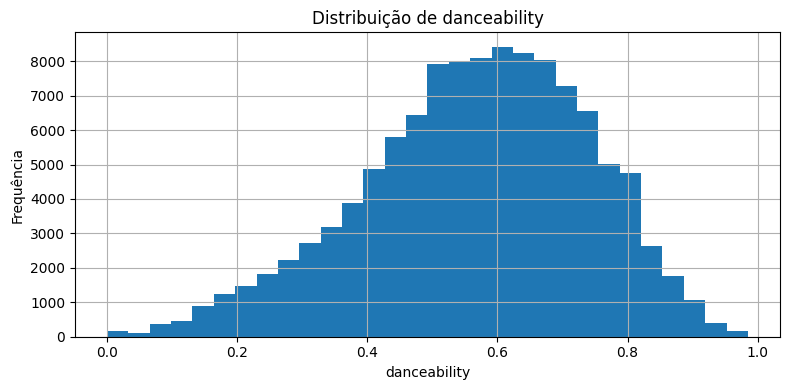

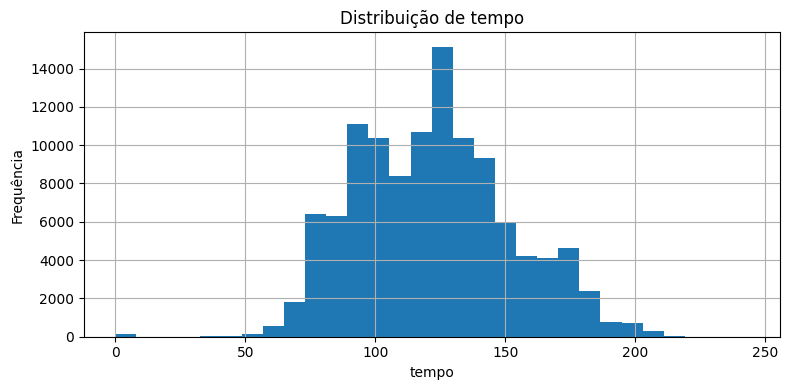

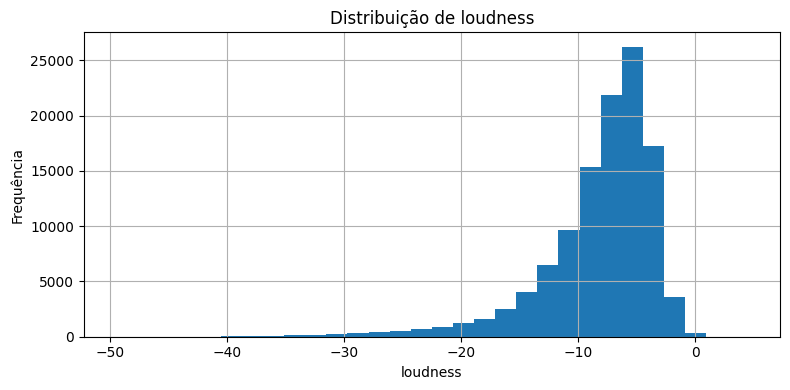

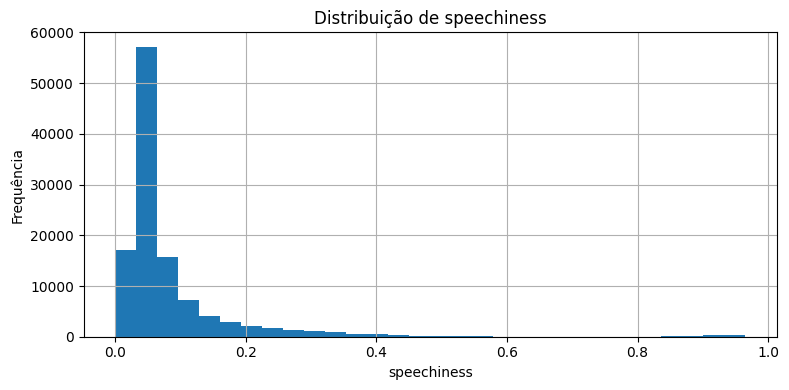


2. Contagem categórica


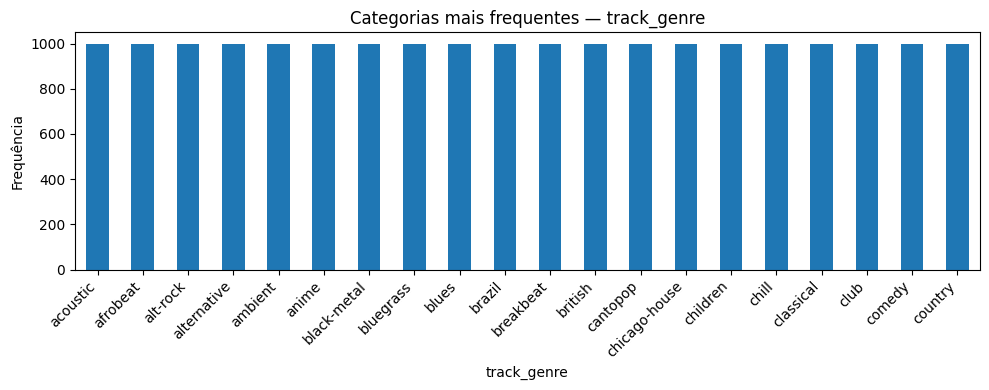

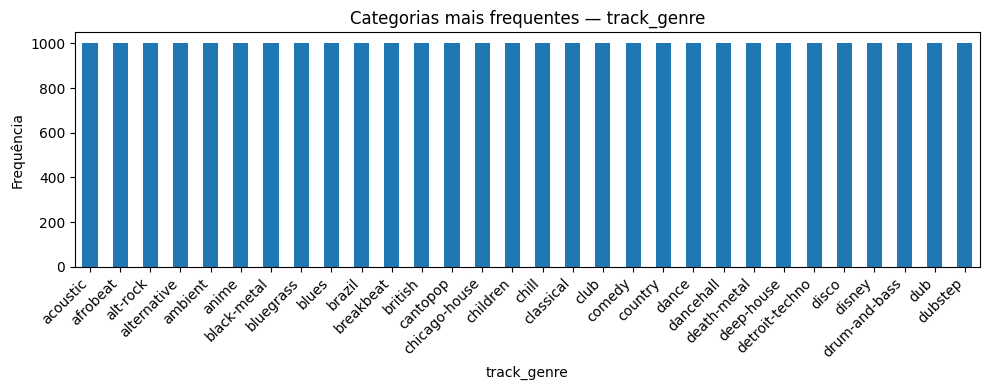

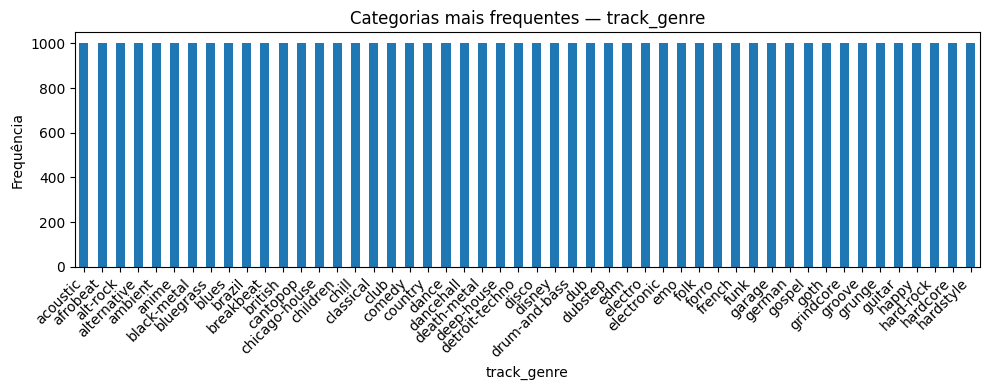


3. Matriz de Correlação...


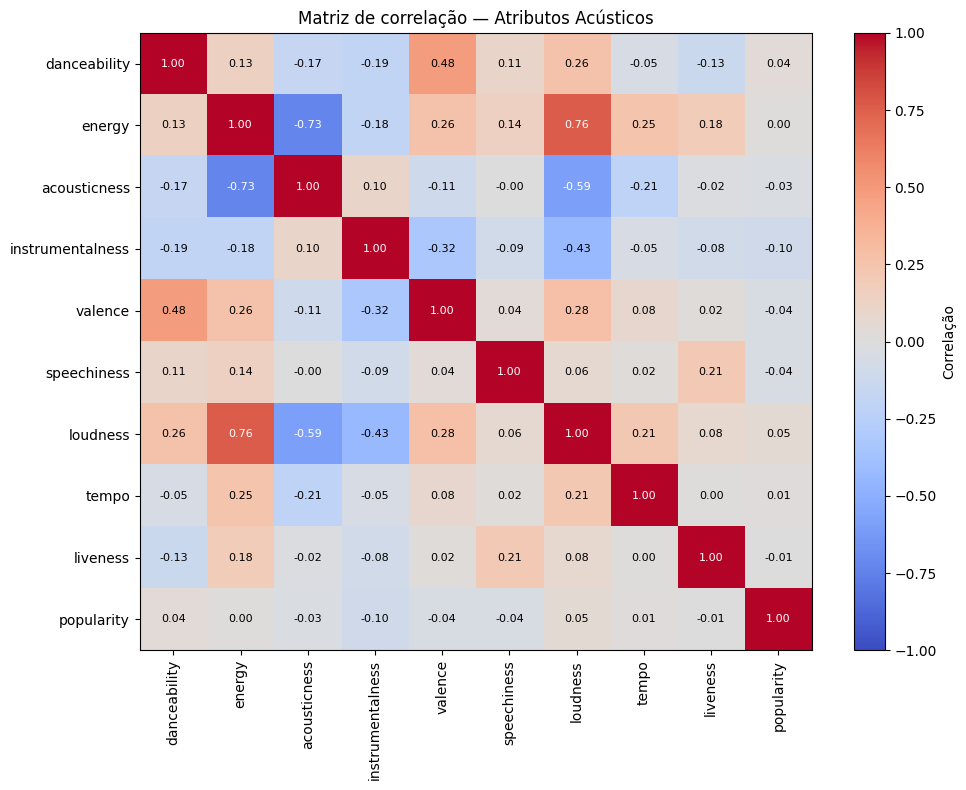


4. Boxplots (Análise de Outliers)


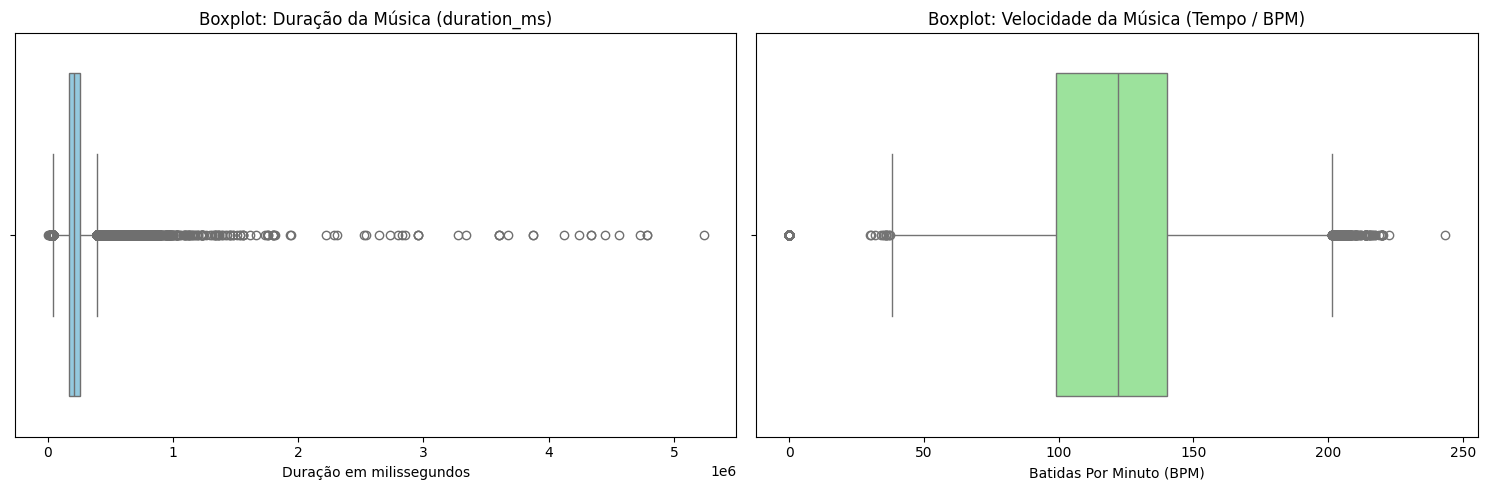


5. Scatter Plot 2D com PCA


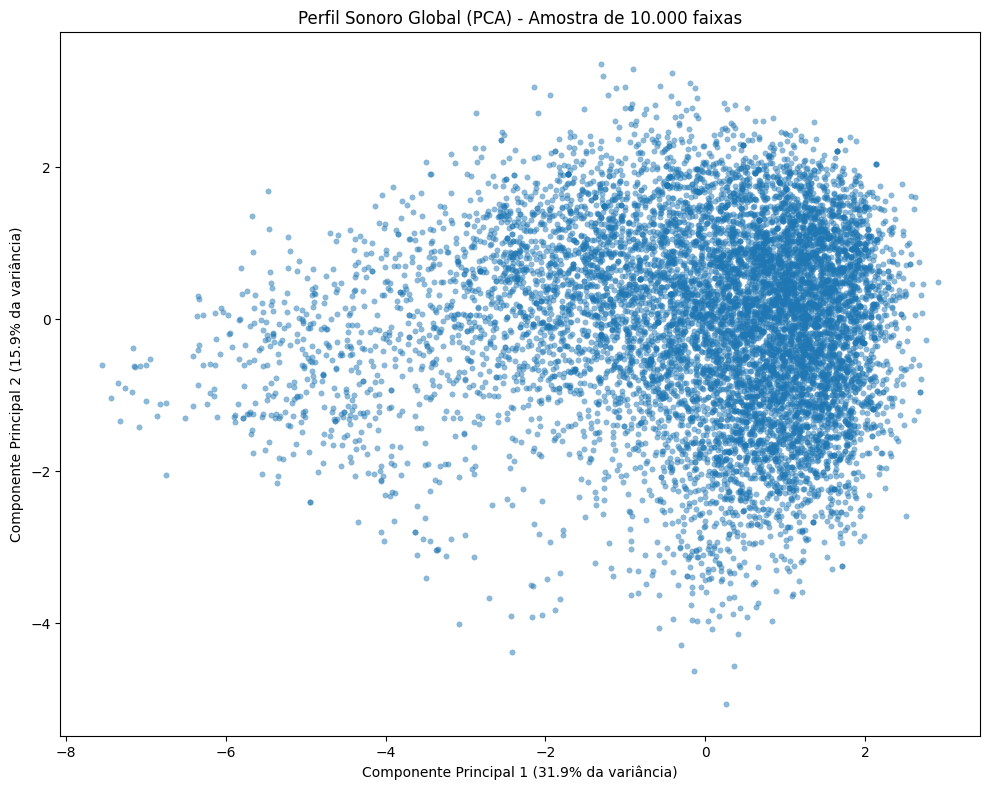

In [6]:
# Funções auxiliares para visualização exploratória
# Adapte as colunas e os gráficos ao dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str, bins: int = 30) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=bins)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    # Usamos as colunas acústicas para a matriz não ficar poluída e ilegível
    colunas_interesse = ['danceability', 'energy', 'acousticness', 'instrumentalness', 
                         'valence', 'speechiness', 'loudness', 'tempo', 'liveness', 'popularity']
    
    numericas = df[colunas_interesse].select_dtypes(include=np.number)
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes para matriz de correlação.")
        return

    corr = numericas.corr()
    plt.figure(figsize=(10, 8))
    cax = plt.imshow(corr, aspect="auto", cmap='coolwarm', vmin=-1, vmax=1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar(cax, label="Correlação")
    
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', 
                     color='black' if abs(corr.iloc[i, j]) < 0.5 else 'white', fontsize=8)

    plt.title("Matriz de correlação — Atributos Acústicos")
    plt.tight_layout()
    plt.show()

print("1. Distribuições numéricas")
plot_distribuicao_numerica(df, "danceability")
plot_distribuicao_numerica(df, "tempo")
plot_distribuicao_numerica(df, "loudness")
plot_distribuicao_numerica(df, "speechiness")

print("\n2. Contagem categórica")
plot_contagem_categorica(df, "track_genre", top_n=20)
plot_contagem_categorica(df, "track_genre", top_n=30)
plot_contagem_categorica(df, "track_genre", top_n=50)

print("\n3. Matriz de Correlação...")
plot_matriz_correlacao(df)

print("\n4. Boxplots (Análise de Outliers)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PRIMEIRO boxplot
sns.boxplot(
    x=df['duration_ms'],
    ax=axes[0],
    color='skyblue'
)

axes[0].set_title('Boxplot: Duração da Música (duration_ms)')
axes[0].set_xlabel('Duração em milissegundos')

# SEGUNDO boxplot
sns.boxplot(
    x=df['tempo'],
    ax=axes[1],
    color='lightgreen'
)

axes[1].set_title('Boxplot: Velocidade da Música (Tempo / BPM)')
axes[1].set_xlabel('Batidas Por Minuto (BPM)')

plt.tight_layout()
plt.show()
print("\n5. Scatter Plot 2D com PCA")

colunas_pca = [
    'danceability', 'energy', 'acousticness',
    'instrumentalness', 'valence', 'speechiness',
    'loudness', 'tempo', 'liveness'
]

df_pca = df[colunas_pca].dropna()

# Padronização
scaler = StandardScaler()
dados_escalados = scaler.fit_transform(df_pca)

# PCA
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(dados_escalados)

df_plot_pca = pd.DataFrame(
    componentes_principais,
    columns=['Componente_1', 'Componente_2']
)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_plot_pca.sample(n=10000, random_state=42),
    x='Componente_1',
    y='Componente_2',
    alpha=0.5,
    s=15,
    edgecolor=None
)

var_x = pca.explained_variance_ratio_[0] * 100
var_y = pca.explained_variance_ratio_[1] * 100

plt.title('Perfil Sonoro Global (PCA) - Amostra de 10.000 faixas')

plt.xlabel(f'Componente Principal 1 ({var_x:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({var_y:.1f}% da variância)')

plt.tight_layout()
plt.show()

## 2.2 Análise visual e principais insights

- **Há distribuições muito assimétricas?** Sim. O histograma de speechiness apresenta uma fortíssima assimetria positiva (à direita), com a esmagadora maioria das músicas concentrando-se em valores próximos a 0.0 e uma cauda longa que se estende até 1.0. De forma oposta, a distribuição de loudness apresenta uma assimetria negativa (à esquerda), com um pico em torno de -5 dB e uma cauda longa de valores negativos que chega a ultrapassar -40 dB;

- **Existem valores extremos relevantes?** Sim. Os boxplots evidenciam uma grande quantidade de valores extremos (outliers). No boxplot de duration_ms, há uma densa linha de outliers além do limite superior, indicando músicas excepcionalmente longas (chegando a valores próximos a 5 milhões de milissegundos). No boxplot de tempo, nota-se a presença de extremos em ambas as pontas da distribuição, com faixas abaixo de 50 BPM e acima de 200 BPM;

- **Existem categorias raras?** Não. A inspeção do gráfico de barras de track_genre revela um comportamento perfeitamente uniforme. Como testado visualmente para as 20, 30 e até 50 categorias mais frequentes, todas apresentam exatamente a mesma frequência absoluta de 1.000 faixas.

- **Existe desbalanceamento de classes, se houver variável-alvo?** Como o objetivo geral do projeto é aplicar técnicas de agrupamento (clusterização) não supervisionado para identificar padrões, não existe uma variável-alvo. 

- **Há relações visuais relevantes entre atributos?** Sim. A matriz de correlação atesta algumas relações muito fortes:
1. *Forte correlação positiva:* Entre energy e loudness (0.76). Músicas mais intensas e energéticas são visualmente mais altas em decibéis. Há também uma correlação positiva moderada entre danceability e valence (0.48), sugerindo que músicas mais dançantes tendem a ter uma sonoridade mais positiva/alegre.
2. *Forte correlação negativa:* Entre energy e acousticness (-0.73), bem como entre loudness e acousticness (-0.59). Isso comprova que faixas com alta probabilidade de serem acústicas quase nunca são barulhentas ou altamente energéticas;

- **Alguma visualização indica limitação da análise?** Sim, duas visualizações indicam limitações claras:
1. *Diferença de Escalas:* A comparação entre o histograma de danceability (escala contínua restrita de 0.0 a 1.0) e o histograma de tempo (que ultrapassa 200 BPM) demonstra visualmente a necessidade obrigatória de normalização antes de aplicar algoritmos baseados em cálculo de distânci;.
2. *Sobreposição Global (PCA)*: O gráfico de dispersão 2D com PCA (Amostra de 10.000 faixas) revela que os dados não formam nuvens separadas. Em vez disso, formam uma única massa contínua. Isso impõe uma grande limitação aos algoritmos de agrupamento, indicando que a separação dos clusters será complexa, exigindo validação rigorosa por métricas como o Silhouette Score.

In [7]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 114000,
  "n_colunas": 21,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [
    "artists",
    "album_name",
    "track_name"
  ],
  "colunas_possiveis_ids": [
    "Unnamed: 0"
  ]
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes em *track_name, album_name, artists* | A função de diagnóstico e o resumo estrutural apontaram apenas 1 linha contendo valores nulos (NaN) em toda a base (0.0%) | REMOVER (a linha) | Como representa um único registro em 114.000, a exclusão da mesma não causa impacto na volumetria geral e evita falhas de execução nos algoritmos |
| Duplicatas |A coluna track_id possui apenas 89.741 valores únicos em 114.000 registros, indicando cerca de 24 mil repetições (músicas categorizadas em múltiplos gêneros) | REMOVER (baseado no ID) | Músicas repetidas formariam clusters artificiais e densos, distorcendo o cálculo de distâncias. Manteremos apenas a primeira ocorrência de cada track_id. |
| Outliers | Boxplots de duration_ms e tempo demonstraram valores extremos matemáticos (ex: músicas muito longas ou com BPM atípicos, ultrapassando 200). | MANTER | Não são "erros", mas perfis musicais reais fornecidos pela API do Spotify. O impacto matemático desses ruídos será resolvidp pelo uso de algoritmos baseados em densidade. |
| Alta cardinalidade |Atributos de texto como track_name e artists possuem milhares de categorias únicas na tabela | MANTER | São dados categóricos que não serão utilizados no cálculo de distâncias. Serão excluídos da etapa de modelagem, mas mantidos na base final para posterior rotulação e interpretação dos clusters |
| Atributos identificadores | O diagnóstico automático identificou a coluna Unnamed: 0 com 100% de unicidade e revelou o track_id como ID de negócio | REMOVER / ISOLAR| A coluna Unnamed: 0 será deletada por ser lixo residual de exportação. O track_id não será usado para cálculos nos algoritmos de clusterização. |
| Atributos sensíveis | A coluna categórica explicit revela conteúdo adulto. O atributo numérico popularity reflete sucesso de mercado, e não sonoridade acústica. | MANTER (mas isolar) | Serão excluídas do cálculo matemático de agrupamento. Contudo, continuarão no dataset para apoiar a análise pós-modelagem. |

### Observação sobre responsabilidade

As decisões de qualidade dos dados tomadas nesta etapa relacionam-se diretamente com as diretrizes de IA Responsável escolhidas para o projeto: Monitoramento e Avaliação e Explicabilidade.

A decisão de remover as músicas duplicadas e isolar o viés de popularidade (popularity) foi fundamental para garantir um Monitoramento e Avaliação justos. Em problemas de clusterização geométrica, a presença de registros duplicados infla artificialmente métricas de avaliação matemática (como o Silhouette Score), fazendo o modelo parecer melhor do que realmente é, pois a distância entre dois pontos idênticos é sempre zero. Além disso, agrupar faixas baseando-se no sucesso comercial e não na sonoridade desvirtuaria a avaliação técnica proposta, que busca padrões físicos do áudio.

Por outro lado, a decisão de não excluir permanentemente do dataset as colunas de alta cardinalidade (track_name, artists), nem a variável sensível de restrição de idade (explicit) ou a própria popularity, ancora-se fortemente na diretriz de Explicabilidade. Isolar esses atributos durante o cálculo estatístico e resgatá-los ao final permite interpretar melhor cada grupo acústico formado. Isso possibilitará explicar ao usuário de negócios dinâmicas complexas, como, por exemplo, se um cluster formado majoritariamente por sons de alta energia e altos decibéis (loudness) tende a apresentar maiores níveis de conteúdo explícito ou se faixas acústicas possuem menor popularidade média.

In [8]:
# Preparação final dos dados
# Esta função deve ser adaptada pelo grupo.
# Não use transformações automáticas sem justificar no texto.

def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        raise ValueError("Dataset não carregado.")

    df_prep = df.copy()

    # 1. Remoção de duplicatas
    # Justificativa (Seção 2.3): Remoção baseada no identificador primário 'track_id', para evitar clusters densos artificiais compostos pela mesma música repetida em gêneros diferentes.
    if 'track_id' in df_prep.columns:
        df_prep = df_prep.drop_duplicates(
            subset=['track_id'],
            keep='first'
        )

    # 2. Remoção de colunas identificadoras, irrelevantes ou problemáticas.
    # Justificativa (Seção 2.3): A coluna 'Unnamed: 0' é apenas um índice residual de exportação e não possui qualquer valor analítico.
    colunas_remover = ['Unnamed: 0']

    colunas_existentes = [
        c for c in colunas_remover
        if c in df_prep.columns
    ]

    df_prep = df_prep.drop(
        columns=colunas_existentes
    )

    # 3. Tratamento de nulos
    # Justificativa (Seção 2.3): O diagnóstico provou haver apenas 1 linha com nulo na base inteira, optou-se pela remoção simples da instância (drop) em vez de imputação estatística.
    df_prep = df_prep.dropna()

    # 4. Padronização / Normalização de Variáveis Numéricas (Requisito da Fase 1 e 2)
    # Justificativa: Equalizar a diferença de escalas geométricas (ex: 'tempo' em BPM vs 'danceability' 0-1)
    colunas_acusticas = [
        'danceability',
        'energy',
        'acousticness',
        'instrumentalness',
        'valence',
        'speechiness',
        'loudness',
        'tempo',
        'liveness'
    ]

    colunas_acusticas = [
        c for c in colunas_acusticas
        if c in df_prep.columns
    ]

    if len(df_prep) > 0 and len(colunas_acusticas) > 0:

        scaler = StandardScaler()

        df_prep[colunas_acusticas] = (
            scaler.fit_transform(
                df_prep[colunas_acusticas]
            )
        )

    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_final(df)
display(df_prep.head())
print(df_prep.shape)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.644253,-0.675975,1,0.335727,0,0.490458,-0.875166,-0.535482,0.723656,0.934047,-1.133599,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,-0.804604,-1.825602,1,-1.673087,1,-0.098364,1.760810,-0.535468,-0.595078,-0.770269,-1.479843,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,-0.702731,-1.073473,0,-0.236524,1,-0.280219,-0.349626,-0.535485,-0.512978,-1.329497,-1.518259,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,-1.676182,-2.240247,0,-1.918228,1,-0.451480,1.704650,-0.535266,-0.436009,-1.241999,1.981635,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.315996,-0.746122,2,-0.226373,1,-0.307585,0.415925,-0.535485,-0.687954,-1.150696,-0.070030,4,acoustic


(89740, 20)


## 2.4 Justificativa da preparação final

- **Quais colunas foram removidas:** A única coluna permanentemente excluída do dataset foi a Unnamed: 0, identificada como um índice numérico residual da exportação do Kaggle que não possuía qualquer relevância para a análise acústica;
- **Como valores ausentes foram tratados:** O diagnóstico de qualidade detectou que apenas 1 linha, em 114.000, possuía valores nulos (nas colunas track_name, album_name e artists). Optou-se pela exclusão direta dessa linha (dropna()). Esta decisão foi tomada porque a remoção de uma única linha não gera impacto estatístico no volume dos dados;
- **Se houve normalização, discretização, codificação ou agregação:** Não houve necessidade de discretização, agregação ou codificação. No entanto, aplicou-se a normalização (padronização com StandardScaler) sobre os nove atributos numéricos contínuos de perfil sonoro (danceability, energy, acousticness, instrumentalness, valence, speechiness, loudness, tempo, liveness). Esta etapa é obrigatória para equalizar as escalas e impedir que variáveis com amplitudes maiores dominem o cálculo de distância em relação a variáveis limitadas de 0 a 1;
- **Como os dados foram preparados para a tarefa específica (Clusterização):** O principal obstáculo para a clusterização era o excesso de densidade artificial provocado por músicas repetidas (faixas classificadas em múltiplos gêneros). Para resolver isso, removemos cerca de 24.000 duplicatas exatas utilizando a coluna track_id como base. Além disso, as colunas textuais (track_name, artists, etc.) e atributos de mercado/sensíveis (popularity e explicit) foram intencionalmente mantidos no dataset, mas isolados da matriz matemática de cálculo dos algoritmos;
- **Quais decisões vieram da baseline:** A abordagem inicial (baseline) forneceu um código genérico que propunha a imputação de nulos com medianas para variáveis numéricas e o preenchimento com "desconhecido" para variáveis textuais. Nenhuma delas foi utilizada pela grupo;
- **Quais vieram da trilha guiada:** Através das diretrizes de Monitoramento e Explicabilidade
, decidimos isolar a variável popularity do cálculo estatístico. Se não o fizéssemos, agruparíamos as músicas pelo seu sucesso comercial enviesado, e não pela sua física acústica original. Contudo, guiados pela necessidade de explicar os clusters, garantimos que os metadados textuais e sensíveis permanecessem na tabela final para apoiar a rotulação e a interpretação humana dos grupos musicais formados;
- **Quais foram decisões próprias do grupo/Quais sugestões da LLM foram corrigidas ou descartadas:**  O grupo optou por rejeitar o tratamento automático de valores ausentes inicialmente sugerido pelo script baseline da LLM. Como a etapa de diagnóstico indicou a existência de apenas uma observação com valores nulos em toda a base, decidiu-se pela remoção direta da instância (dropna()), evitando imputações desnecessárias que poderiam introduzir ruído nos dados.
Além disso, o script inicial não identificou adequadamente a necessidade de tratar a coluna track_id como identificador único, devido à presença de músicas repetidas em diferentes gêneros. Dessa forma, o grupo decidiu aplicar drop_duplicates() em track_id, preservando apenas uma ocorrência por faixa e reduzindo a criação artificial de regiões densas na análise.

In [11]:
# Como o objetivo do trabalho é agrupamento (clusterização), o grupo removeu a função gerar_transacoes_de_coluna.
# Além disso, o grupo optou por não utilizar pd.get_dummies() para codificação automática das variáveis categóricas.

def preparar_matriz_modelagem(
    df: pd.DataFrame
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    df_model = df.copy()

    colunas_acusticas = [
        'danceability',
        'energy',
        'acousticness',
        'instrumentalness',
        'valence',
        'speechiness',
        'loudness',
        'tempo',
        'liveness'
    ]

    colunas_acusticas = [
        c for c in colunas_acusticas
        if c in df_model.columns
    ]

    X = df_model[colunas_acusticas]

    df_metadados = (
        df_model
        .drop(columns=colunas_acusticas)
    )

    return X, df_metadados

X, df_metadados = preparar_matriz_modelagem(df_prep)

print("--- MATRIZES PREPARADAS PARA A FASE 4 (MODELAGEM) ---")
print(f"Formato da matriz X (Apenas colunas matemáticas): {X.shape}")
print(f"Formato dos Metadados (Para interpretar os clusters depois): {df_metadados.shape}")

print("\nMatriz X:")
display(X.head())

--- MATRIZES PREPARADAS PARA A FASE 4 (MODELAGEM) ---
Formato da matriz X (Apenas colunas matemáticas): (89740, 9)
Formato dos Metadados (Para interpretar os clusters depois): (89740, 11)

Matriz X:


,danceability,energy,acousticness,instrumentalness,valence,speechiness,loudness,tempo,liveness
0,0.644253,-0.675975,-0.875166,-0.535482,0.934047,0.490458,0.335727,-1.133599,0.723656
1,-0.804604,-1.825602,1.760810,-0.535468,-0.770269,-0.098364,-1.673087,-1.479843,-0.595078
2,-0.702731,-1.073473,-0.349626,-0.535485,-1.329497,-0.280219,-0.236524,-1.518259,-0.512978
3,-1.676182,-2.240247,1.704650,-0.535266,-1.241999,-0.451480,-1.918228,1.981635,-0.436009
4,0.315996,-0.746122,0.415925,-0.535485,-1.150696,-0.307585,-0.226373,-0.070030,-0.687954


# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | K-Means com número de clusters definido pelo elbow method; menção a DBSCAN sem ajuste de hiperparâmetros | K-Means com métricas complementares (Silhouette e Davies-Bouldin); uso de DBSCAN como controle de ruído; sugestão de GMM para clusters sobrepostos | K-Means, DBSCAN, GMM e Hierarchical Clustering (sobre amostra) | A decisão final sobre o algoritmo principal será tomada com base nos resultados obtidos na Seção 3.3. |
| Preparação dos dados | Normalização com StandardScaler; remoção de nulos por imputação com mediana | Normalização com StandardScaler; remoção de duplicatas por track_id; exclusão de popularity e track_id antes da modelagem | StandardScaler nas 9 variáveis acústicas; remoção de duplicatas por track_id; exclusão de popularity, track_id e colunas textuais da matriz de modelagem | A exclusão de popularity foi motivada pela diretriz de Explicabilidade para evitar viés comercial; imputação foi desnecessária pois havia apenas 1 nulo. |
| Parâmetros | k=5 definido pelo elbow method sem validação adicional; DBSCAN com eps=0.5, min_samples=5 sem ajuste | k avaliado de 2 a 12 por Silhouette; DBSCAN com busca de eps via curva de k-distância | k avaliado de 2 a 14 por Silhouette e Davies-Bouldin; DBSCAN com eps definido pela curva de k-distância (K_NN=min_samples=10); GMM com n_components avaliado independentemente pelo BIC | Parâmetros validados empiricamente com múltiplas métricas, não fixados a priori. |
| Métricas | Apenas Inertia (elbow method) e Silhouette Score | Silhouette Score, Davies-Bouldin Index e análise qualitativa dos centroides | Silhouette Score, Davies-Bouldin Index, análise dos centroides, interpretação semântica e análise de estabilidade com 5 sementes | Combinar métricas quantitativas com interpretação qualitativa alinha-se às diretrizes de Monitoramento e Explicabilidade. |
| Estratégia de avaliação | Avaliação pontual em um único experimento | Comparação entre algoritmos; análise de centroides; sugestão de validação visual com PCA | Comparação entre 4 algoritmos com métricas próprias de cada um; interpretação semântica dos clusters; análise de estabilidade; PCA apenas exploratório | Cada algoritmo é avaliado com a lógica adequada à sua natureza, sem forçar comparações artificiais de parâmetros. |
| Cuidados de IA responsável | Não citados explicitamente | Sugerida remoção de popularity; proposta de auditoria dos clusters | Exclusão de popularity da matriz de modelagem; auditoria semântica dos clusters; análise de estabilidade entre sementes | Operacionalização concreta das duas diretrizes escolhidas: Monitoramento/Avaliação e Explicabilidade. |

### Síntese da decisão final

Quatro algoritmos serão testados para identificar qual melhor representa a estrutura sonora do dataset: **K-Means**, **DBSCAN**, **GMM** e **Hierarchical Clustering** (sobre amostra de 5.000 registros). Cada algoritmo foi avaliado com critérios adequados à sua natureza, K-Means e GMM por Silhouette e Davies-Bouldin, DBSCAN pela curva de k-distância e percentual de ruído, Hierarchical pelo dendrograma e métricas sobre amostra. A escolha do algoritmo principal e do número de clusters é apresentada na Seção 3.5, após os experimentos.

A abordagem difere da baseline por não depender exclusivamente do elbow method e por ajustar os parâmetros do DBSCAN. Se diferencia da guiada por incluir GMM e por realizar análise de estabilidade com múltiplas sementes, não propostos pela LLM.


In [12]:
# Registro de experimentos
import os, json, time
from datetime import datetime

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
experimentos = []

def registrar_experimento(nome, algoritmo, parametros, metricas, observacoes=""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro

def salvar_experimentos(caminho=os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

print("Módulo de rastreabilidade carregado.")

Módulo de rastreabilidade carregado.


## 3.2 Modelagem para padrões frequentes

Use esta seção se o TP atual for de mineração de padrões frequentes.

Caso o TP seja de agrupamento ou classificação, mantenha apenas como referência e utilize as seções correspondentes abaixo.

In [ ]:
# Modelagem para padrões frequentes: Apriori e FP-Growth
# Esta célula depende de mlxtend. Instale se necessário: pip install mlxtend


def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada. Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo_segundos": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo_segundos": tempo_fpgrowth
    }

    return resultados


def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# resultados_padroes = executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6)
# resumo_padroes = resumir_padroes_frequentes(resultados_padroes)
# display(resumo_padroes)

## 3.3 Modelagem para agrupamento

Use esta seção se o TP atual for de clusterização.

A avaliação de agrupamento deve considerar métricas internas, interpretação dos grupos e coerência com o problema. Não basta reportar o número de clusters.

Esta seção implementa a **solução final** de clusterização.  
Os algoritmos executados são: **K-Means**, **DBSCAN**, **GMM** e **Hierarchical Clustering** (sobre amostra).

A escolha do número de clusters k é feita a partir da análise do **Silhouette Score** e do **Davies-Bouldin Index** para k ∈ {2, …, 12}.  
Todos os experimentos são registrados para garantir rastreabilidade (diretriz de Monitoramento e Avaliação).

Avaliando valores de k para K-Means...
  k= 2 | Silhouette=0.2611 | Davies-Bouldin=1.5699 | Inertia=632,735
  k= 3 | Silhouette=0.1642 | Davies-Bouldin=1.9059 | Inertia=561,696
  k= 4 | Silhouette=0.1710 | Davies-Bouldin=1.6969 | Inertia=505,598
  k= 5 | Silhouette=0.1774 | Davies-Bouldin=1.5165 | Inertia=455,891
  k= 6 | Silhouette=0.1884 | Davies-Bouldin=1.4436 | Inertia=414,346
  k= 7 | Silhouette=0.1949 | Davies-Bouldin=1.3829 | Inertia=377,050
  k= 8 | Silhouette=0.1769 | Davies-Bouldin=1.3881 | Inertia=356,486
  k= 9 | Silhouette=0.1808 | Davies-Bouldin=1.3730 | Inertia=337,944
  k=10 | Silhouette=0.1680 | Davies-Bouldin=1.4343 | Inertia=324,165
  k=11 | Silhouette=0.1695 | Davies-Bouldin=1.4568 | Inertia=312,026
  k=12 | Silhouette=0.1689 | Davies-Bouldin=1.4699 | Inertia=302,258


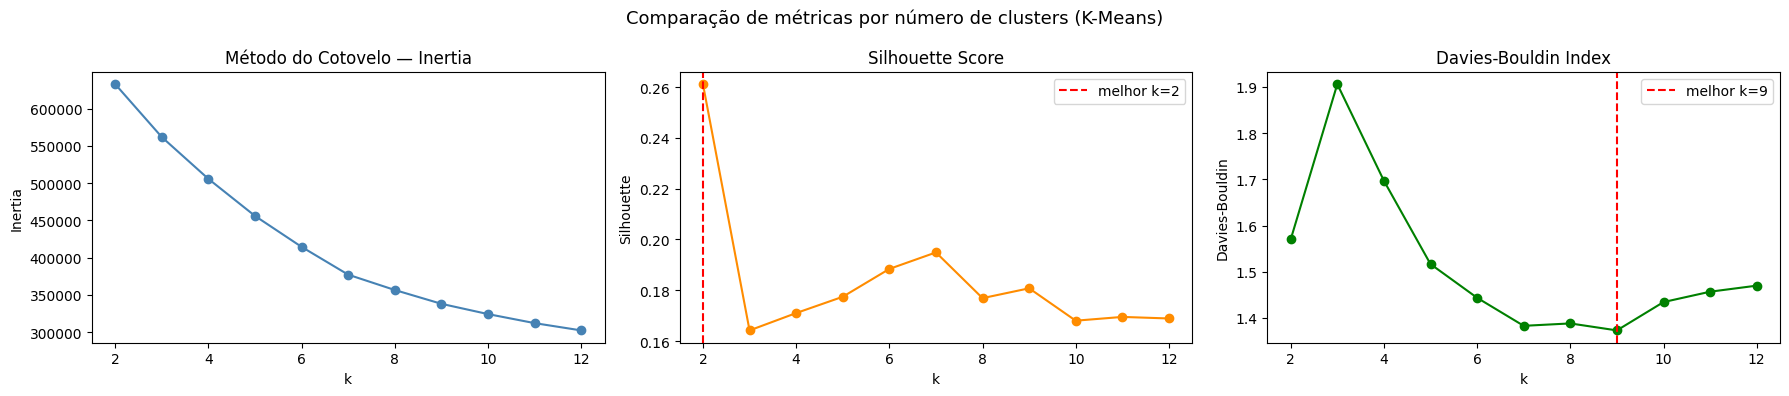


Melhor k por Silhouette: 2
Melhor k por Davies-Bouldin: 9


In [17]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

RANDOM_STATE = 42

# Seleção de k para K-Means
# X está  disponível da Seção 2
K_RANGE = range(2, 13)

resultados_k = []

print("Avaliando valores de k para K-Means...")
for k in K_RANGE:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = modelo.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=10_000, random_state=RANDOM_STATE)
    db  = davies_bouldin_score(X, labels)
    ine = modelo.inertia_
    resultados_k.append({"k": k, "silhouette": sil, "davies_bouldin": db, "inertia": ine})
    print(f"  k={k:2d} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f} | Inertia={ine:,.0f}")

df_k = pd.DataFrame(resultados_k)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(df_k["k"], df_k["inertia"], "o-", color="steelblue")
axes[0].set_title("Método do Cotovelo — Inertia"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(df_k["k"], df_k["silhouette"], "o-", color="darkorange")
best_k_sil = df_k.loc[df_k["silhouette"].idxmax(), "k"]
axes[1].axvline(best_k_sil, color="red", linestyle="--", label=f"melhor k={best_k_sil}")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].legend()

axes[2].plot(df_k["k"], df_k["davies_bouldin"], "o-", color="green")
best_k_db = df_k.loc[df_k["davies_bouldin"].idxmin(), "k"]
axes[2].axvline(best_k_db, color="red", linestyle="--", label=f"melhor k={best_k_db}")
axes[2].set_title("Davies-Bouldin Index"); axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin")
axes[2].legend()

plt.suptitle("Comparação de métricas por número de clusters (K-Means)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "selecao_k.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"\nMelhor k por Silhouette: {best_k_sil}")
print(f"Melhor k por Davies-Bouldin: {best_k_db}")

O k=2 tem o maior Silhouette (0.2611) porque os dados do Spotify naturalmente se dividem em dois grandes grupos quando forçados a escolher, provavelmente algo como "músicas acústicas/calmas" vs "músicas eletrônicas/energéticas", que é a correlação negativa forte (-0.73) que vocês já foi identificado na Seção 2.2 entre energy e acousticness.

O problema é que k=2 é matematicamente melhor mas semanticamente inútil para o objetivo do projeto. Dois clusters não geram valor de negócio para sistemas de recomendação ou organização de playlists.

Olhando os dados, k=7 é provavelmente a melhor escolha pois
- Silhouette de 0.1949, segundo maior, bem próximo do k=2
- Davies-Bouldin de 1.3829, o menor de todos (melhor separação)
- Ainda interpretável semanticamente com 7 perfis sonoros

In [18]:
# K-Means final com melhor K escolhido pela análise acima
K_FINAL = 7  # valor selecionado pela análise acima
print(f"Treinando K-Means final com k={K_FINAL}...")
t0 = time.time()
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
labels_kmeans = kmeans_final.fit_predict(X)
t_kmeans = time.time() - t0

sil_km = silhouette_score(X, labels_kmeans, sample_size=10_000, random_state=RANDOM_STATE)
db_km  = davies_bouldin_score(X, labels_kmeans)

print(f"Silhouette Score : {sil_km:.4f}")
print(f"Davies-Bouldin : {db_km:.4f}")
print(f"Tempo : {t_kmeans:.2f}s")

# Tamanho dos clusters
tamanho_km = pd.Series(labels_kmeans).value_counts().sort_index()
print("\nDistribuição dos clusters K-Means:")
print(tamanho_km.to_string())

registrar_experimento(
    nome="KMeans_final",
    algoritmo="KMeans",
    parametros={"n_clusters": K_FINAL, "n_init": 20, "random_state": RANDOM_STATE},
    metricas={"silhouette": round(sil_km, 4), "davies_bouldin": round(db_km, 4), "tempo_s": round(t_kmeans, 2)},
    observacoes=f"Modelo final. k escolhido pelo máximo Silhouette em {list(K_RANGE)}."
)

Treinando K-Means final com k=7...
Silhouette Score : 0.1949
Davies-Bouldin : 1.3829
Tempo : 2.60s

Distribuição dos clusters K-Means:
0    18118
1    20205
2    27506
3     6206
4     6551
5     1045
6    10109


{'timestamp': '2026-05-29T18:54:13',
 'nome': 'KMeans_final',
 'algoritmo': 'KMeans',
 'parametros': {'n_clusters': 7, 'n_init': 20, 'random_state': 42},
 'metricas': {'silhouette': 0.1949, 'davies_bouldin': 1.3829, 'tempo_s': 2.6},
 'observacoes': 'Modelo final. k escolhido pelo máximo Silhouette em [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12].'}

Calculando curva de k-distância para eps ótimo (k=10)...


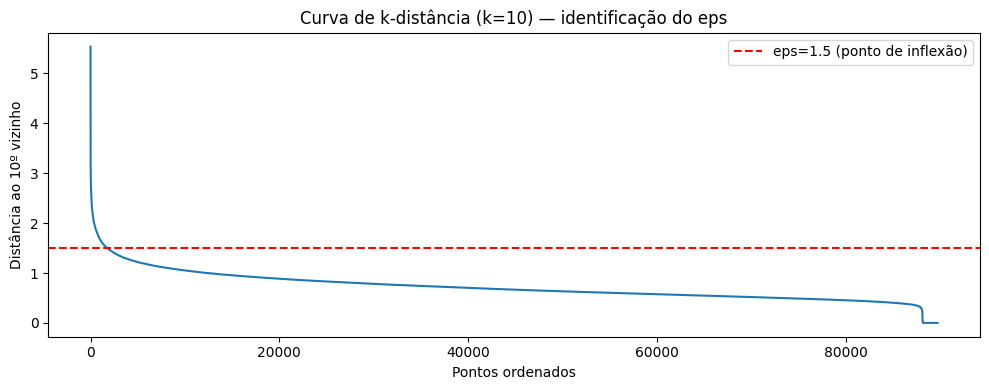


Executando DBSCAN com eps=1.5, min_samples=10...
  Clusters encontrados : 6
  Ruído (-1)           : 649 (0.7%)
  Tempo                : 84.26s
  Silhouette (sem ruído): 0.2268
  Davies-Bouldin        : 0.7941


{'timestamp': '2026-05-29T19:03:02',
 'nome': 'DBSCAN_eps1.5',
 'algoritmo': 'DBSCAN',
 'parametros': {'eps': 1.5, 'min_samples': 10},
 'metricas': {'n_clusters': 6,
  'n_noise': 649,
  'pct_noise': np.float64(0.72),
  'silhouette': 0.2268,
  'davies_bouldin': 0.7941,
  'tempo_s': 84.26},
 'observacoes': 'eps definido pelo ponto de inflexão da curva k-distância (k=10).'}

In [ ]:
# DBSCAN, busca de eps pela curva de k-distância 

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

print("Calculando curva de k-distância para eps ótimo (k=10)...")
K_NN = 10
nbrs = NearestNeighbors(n_neighbors=K_NN).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.title(f"Curva de k-distância (k={K_NN}) — identificação do eps")
plt.xlabel("Pontos ordenados")
plt.ylabel(f"Distância ao {K_NN}º vizinho")
plt.axhline(y=1.5, color="red", linestyle="--", label="eps=1.5 (ponto de inflexão)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dbscan_kdist.png"), dpi=120, bbox_inches="tight")
plt.show()

# Execução do DBSCAN
EPS = 1.5
MIN_SAMPLES = 10

print(f"\nExecutando DBSCAN com eps={EPS}, min_samples={MIN_SAMPLES}...")
t0 = time.time()
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X)
t_dbscan = time.time() - t0

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise       = (labels_dbscan == -1).sum()
pct_noise     = n_noise / len(labels_dbscan) * 100

print(f"Clusters encontrados: {n_clusters_db}")
print(f"Ruído (-1): {n_noise} ({pct_noise:.1f}%)")
print(f"Tempo: {t_dbscan:.2f}s")

if n_clusters_db > 1:
    mask_valid = labels_dbscan != -1
    sil_db = silhouette_score(X[mask_valid], labels_dbscan[mask_valid],
                              sample_size=10_000, random_state=RANDOM_STATE)
    db_db  = davies_bouldin_score(X[mask_valid], labels_dbscan[mask_valid])
    print(f"Silhouette (sem ruído): {sil_db:.4f}")
    print(f"Davies-Bouldin: {db_db:.4f}")
else:
    sil_db, db_db = float("nan"), float("nan")
    print("Silhouette: N/A (apenas 1 cluster ou nenhum)")

registrar_experimento(
    nome="DBSCAN_eps1.5",
    algoritmo="DBSCAN",
    parametros={"eps": EPS, "min_samples": MIN_SAMPLES},
    metricas={
        "n_clusters": n_clusters_db,
        "n_noise": int(n_noise),
        "pct_noise": round(pct_noise, 2),
        "silhouette": round(sil_db, 4) if not np.isnan(sil_db) else None,
        "davies_bouldin": round(db_db, 4) if not np.isnan(db_db) else None,
        "tempo_s": round(t_dbscan, 2)
    },
    observacoes="eps definido pelo ponto de inflexão da curva k-distância (k=10)."
)


In [26]:
# GMM (Gaussian Mixture Model) 
from sklearn.mixture import GaussianMixture

N_COMP = K_FINAL 

print(f"Executando GMM com n_components={N_COMP}, covariance_type='full'...")
t0 = time.time()
gmm = GaussianMixture(n_components=N_COMP, covariance_type="full",
                      random_state=RANDOM_STATE, n_init=5)
gmm.fit(X)
labels_gmm = gmm.predict(X)
t_gmm = time.time() - t0

sil_gmm = silhouette_score(X, labels_gmm, sample_size=10_000, random_state=RANDOM_STATE)
db_gmm  = davies_bouldin_score(X, labels_gmm)
bic_gmm = gmm.bic(X)
aic_gmm = gmm.aic(X)

print(f"Silhouette Score: {sil_gmm:.4f}")
print(f"Davies-Bouldin: {db_gmm:.4f}")
print(f"BIC: {bic_gmm:,.0f}")
print(f"AIC: {aic_gmm:,.0f}")
print(f"Tempo: {t_gmm:.2f}s")

tamanho_gmm = pd.Series(labels_gmm).value_counts().sort_index()
print("\nDistribuição dos clusters GMM:")
print(tamanho_gmm.to_string())

registrar_experimento(
    nome="GMM_k6",
    algoritmo="GaussianMixture",
    parametros={"n_components": N_COMP, "covariance_type": "full", "n_init": 5, "random_state": RANDOM_STATE},
    metricas={"silhouette": round(sil_gmm, 4), "davies_bouldin": round(db_gmm, 4),
              "bic": round(bic_gmm, 0), "aic": round(aic_gmm, 0), "tempo_s": round(t_gmm, 2)},
    observacoes="GMM com full covariance para capturar formas elipsoidais de clusters."
)


Executando GMM com n_components=7, covariance_type='full'...
Silhouette Score: -0.0357
Davies-Bouldin: 3.4797
BIC: 976,535
AIC: 972,924
Tempo: 95.27s

Distribuição dos clusters GMM:
0    10150
1    18217
2    17953
3     8590
4    14401
5    13115
6     7314


{'timestamp': '2026-05-29T19:17:24',
 'nome': 'GMM_k6',
 'algoritmo': 'GaussianMixture',
 'parametros': {'n_components': 7,
  'covariance_type': 'full',
  'n_init': 5,
  'random_state': 42},
 'metricas': {'silhouette': -0.0357,
  'davies_bouldin': 3.4797,
  'bic': 976535.0,
  'aic': 972924.0,
  'tempo_s': 95.27},
 'observacoes': 'GMM com full covariance para capturar formas elipsoidais de clusters.'}

Executando Hierarchical Clustering (Ward) em amostra de 5000 registros...


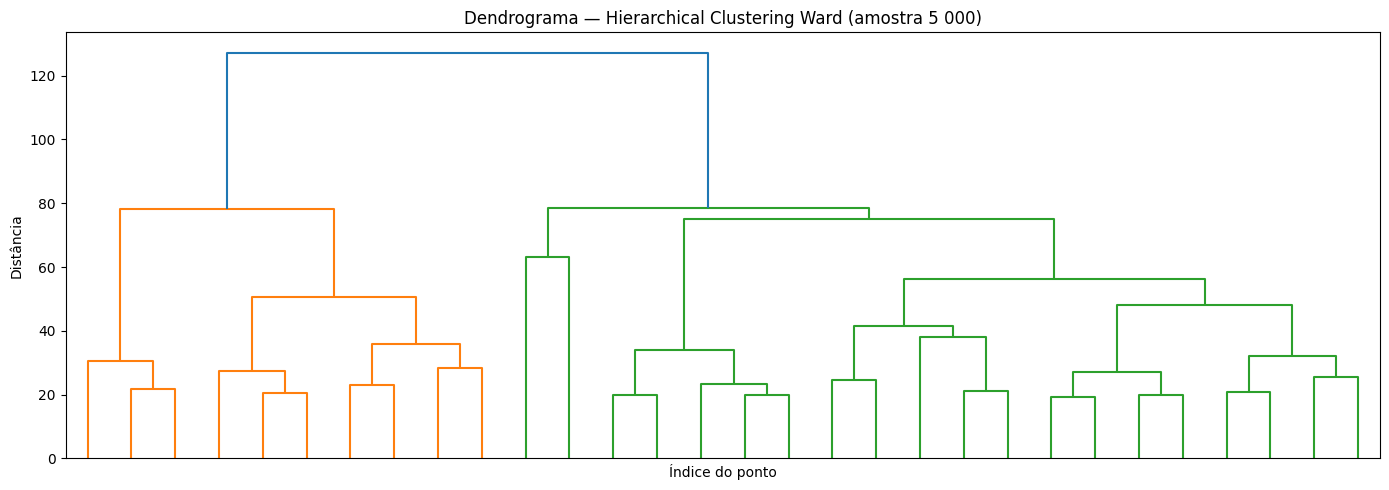

Silhouette Score (amostra): 0.1342
Davies-Bouldin  (amostra): 1.6559
Tempo (amostra): 1.35s


{'timestamp': '2026-05-29T19:08:59',
 'nome': 'Hierarquico_Ward',
 'algoritmo': 'AgglomerativeClustering',
 'parametros': {'n_clusters': 7, 'linkage': 'ward', 'sample_size': 5000},
 'metricas': {'silhouette': 0.1342, 'davies_bouldin': 1.6559, 'tempo_s': 1.35},
 'observacoes': 'Executado apenas sobre amostra de 5 000 por custo computacional O(n³).'}

In [22]:
# Hierarchical Clustering (Ward) 
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

SAMPLE_SIZE = 5_000
print(f"Executando Hierarchical Clustering (Ward) em amostra de {SAMPLE_SIZE} registros...")

# Amostra aleatória reprodutível
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X), size=SAMPLE_SIZE, replace=False)
X_sample = X.iloc[idx_sample] if hasattr(X, "iloc") else X[idx_sample]

# Dendrograma (linkage sobre a amostra)
Z = linkage(X_sample, method="ward")
plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, truncate_mode="lastp", p=30, color_threshold=0.7 * max(Z[:, 2]))
plt.title("Dendrograma — Hierarchical Clustering Ward (amostra 5 000)")
plt.xlabel("Índice do ponto")
plt.ylabel("Distância")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dendrograma.png"), dpi=120, bbox_inches="tight")
plt.show()

# Agglomerative com k=K_FINAL para comparação
t0 = time.time()
hierarq = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_hier_sample = hierarq.fit_predict(X_sample)
t_hier = time.time() - t0

sil_hier = silhouette_score(X_sample, labels_hier_sample)
db_hier  = davies_bouldin_score(X_sample, labels_hier_sample)

print(f"Silhouette Score (amostra): {sil_hier:.4f}")
print(f"Davies-Bouldin  (amostra): {db_hier:.4f}")
print(f"Tempo (amostra): {t_hier:.2f}s")

registrar_experimento(
    nome="Hierarquico_Ward",
    algoritmo="AgglomerativeClustering",
    parametros={"n_clusters": K_FINAL, "linkage": "ward", "sample_size": SAMPLE_SIZE},
    metricas={"silhouette": round(sil_hier, 4), "davies_bouldin": round(db_hier, 4), "tempo_s": round(t_hier, 2)},
    observacoes="Executado apenas sobre amostra de 5 000 por custo computacional O(n³)."
)


In [23]:
# Análise de Estabilidade do K-Means (múltiplas sementes)
print("Análise de estabilidade do K-Means com 5 sementes aleatórias diferentes...")

SEMENTES = [0, 7, 13, 21, 99]
resultados_estab = []

for semente in SEMENTES:
    modelo_s = KMeans(n_clusters=K_FINAL, random_state=semente, n_init=10)
    labels_s = modelo_s.fit_predict(X)
    sil_s = silhouette_score(X, labels_s, sample_size=10_000, random_state=42)
    db_s  = davies_bouldin_score(X, labels_s)
    resultados_estab.append({"semente": semente, "silhouette": sil_s, "davies_bouldin": db_s})

df_estab = pd.DataFrame(resultados_estab)
print("\nResultados de estabilidade:")
display(df_estab.round(4))

print(f"\nSilhouette - média: {df_estab['silhouette'].mean():.4f}, std: {df_estab['silhouette'].std():.4f}")
print(f"Davies-Bouldin — média: {df_estab['davies_bouldin'].mean():.4f}, std: {df_estab['davies_bouldin'].std():.4f}")

if df_estab["silhouette"].std() < 0.01:
    print("\nAlta estabilidade: variação de Silhouette < 0.01 entre sementes.")
else:
    print("\nVariação moderada: verificar sensibilidade à inicialização.")


Análise de estabilidade do K-Means com 5 sementes aleatórias diferentes...

Resultados de estabilidade:


,semente,silhouette,davies_bouldin
0,0,0.1949,1.3829
1,7,0.1949,1.3830
2,13,0.1949,1.3830
3,21,0.1949,1.3827
4,99,0.1949,1.3831



Silhouette - média: 0.1949, std: 0.0000
Davies-Bouldin — média: 1.3829, std: 0.0001

Alta estabilidade: variação de Silhouette < 0.01 entre sementes.


Médias dos atributos normalizados por cluster (espaço Z-score):


,danceability,energy,acousticness,instrumentalness,valence,speechiness,loudness,tempo,liveness
cluster_kmeans,,,,,,,,,
0,-0.195,-1.014,1.061,-0.434,-0.287,-0.295,-0.414,-0.291,-0.292
1,-0.510,0.707,-0.746,-0.423,-0.378,-0.019,0.602,0.584,-0.113
2,0.810,0.320,-0.316,-0.473,0.879,0.079,0.375,-0.122,-0.269
3,-0.241,0.456,-0.111,-0.296,0.129,0.007,0.266,0.039,2.710
4,-1.262,-1.814,1.574,1.886,-1.108,-0.322,-2.460,-0.660,-0.276
5,0.057,0.158,1.235,-0.513,-0.105,6.690,-0.523,-0.702,2.316
6,0.125,0.412,-0.628,1.922,-0.473,-0.135,0.005,0.163,-0.242


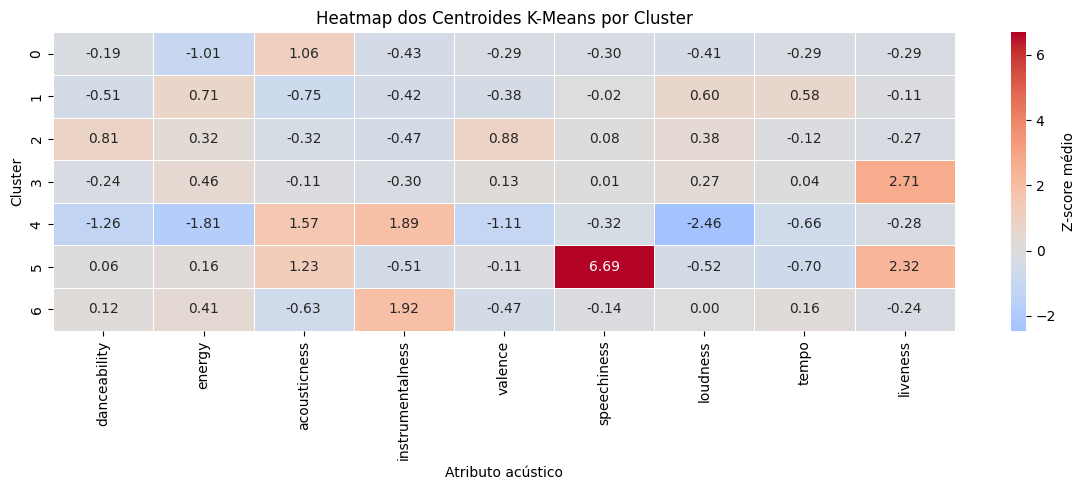

In [24]:
# Interpretação semântica dos clusters K-Means 
df_resultado = df_metadados.copy()
df_resultado["cluster_kmeans"] = labels_kmeans
colunas_acusticas = list(X.columns)
df_resultado_feat = df_resultado.copy()
df_resultado_feat[colunas_acusticas] = X.values  # X já normalizado
centroides = df_resultado_feat.groupby("cluster_kmeans")[colunas_acusticas].mean()

print("Médias dos atributos normalizados por cluster (espaço Z-score):")
display(centroides.round(3))

# Heatmap dos centroides
plt.figure(figsize=(12, 5))
import seaborn as sns
sns.heatmap(centroides, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Z-score médio"})
plt.title("Heatmap dos Centroides K-Means por Cluster")
plt.xlabel("Atributo acústico")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "centroides_heatmap.png"), dpi=120, bbox_inches="tight")
plt.show()


In [28]:
# Tabela comparativa final entre algoritmos 
tabela_final = pd.DataFrame([
    {
        "Algoritmo": "K-Means (k=7)",
        "N° Clusters": K_FINAL,
        "Silhouette": round(sil_km, 4),
        "Davies-Bouldin": round(db_km, 4),
        "% Ruído": "0%",
        "Escalável?": "Sim",
        "Interpretável?": "Alta",
        "Tempo (s)": round(t_kmeans, 2)
    },
    {
        "Algoritmo": f"DBSCAN (eps={EPS})",
        "N° Clusters": n_clusters_db,
        "Silhouette": round(sil_db, 4) if not np.isnan(sil_db) else "N/A",
        "Davies-Bouldin": round(db_db, 4) if not np.isnan(db_db) else "N/A",
        "% Ruído": f"{pct_noise:.1f}%",
        "Escalável?": "Sim",
        "Interpretável?": "Média",
        "Tempo (s)": round(t_dbscan, 2)
    },
    {
        "Algoritmo": f"GMM (k={N_COMP})",
        "N° Clusters": N_COMP,
        "Silhouette": round(sil_gmm, 4),
        "Davies-Bouldin": round(db_gmm, 4),
        "% Ruído": "0%",
        "Escalável?": "Médio",
        "Interpretável?": "Média",
        "Tempo (s)": round(t_gmm, 2)
    },
    {
        "Algoritmo": f"Hierarchical Ward (k={K_FINAL}, amostra 5k)",
        "N° Clusters": K_FINAL,
        "Silhouette": round(sil_hier, 4),
        "Davies-Bouldin": round(db_hier, 4),
        "% Ruído": "0%",
        "Escalável?": "Não",
        "Interpretável?": "Alta",
        "Tempo (s)": round(t_hier, 2)
    },
])

print("Tabela comparativa final entre algoritmos:")
display(tabela_final)
tabela_final.to_csv(os.path.join(OUTPUT_DIR, "comparativo_algoritmos.csv"), index=False)
salvar_experimentos()


Tabela comparativa final entre algoritmos:


,Algoritmo,N° Clusters,Silhouette,Davies-Bouldin,% Ruído,Escalável?,Interpretável?,Tempo (s)
0,K-Means (k=7),7,0.1949,1.3829,0%,Sim,Alta,2.60
1,DBSCAN (eps=1.5),6,0.2268,0.7941,0.7%,Sim,Média,84.26
2,GMM (k=7),7,-0.0357,3.4797,0%,Médio,Média,95.27
3,"Hierarchical Ward (k=7, amostra 5k)",7,0.1342,1.6559,0%,Não,Alta,1.35


Experimentos salvos em: outputs/experimentos.json


## 3.4 Modelagem para classificação

Use esta seção se o TP atual for de classificação.

A avaliação deve usar uma separação adequada entre treino e teste ou validação cruzada, além de métricas coerentes com o problema, especialmente se houver desbalanceamento de classes.

In [ ]:
# Modelagem para classificação: exemplos com árvore, regressão logística e random forest
# Adapte os modelos conforme a proposta do grupo.


def executar_classificacao_basica(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    modelos = {
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    }

    resultados = []
    modelos_treinados = {}

    average = "weighted" if y.nunique() > 2 else "binary"

    for nome, modelo in modelos.items():
        inicio = time.time()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        tempo = time.time() - inicio

        resultados.append({
            "modelo": nome,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
            "tempo_segundos": tempo
        })

        modelos_treinados[nome] = modelo

    return pd.DataFrame(resultados), modelos_treinados

# Exemplo de uso:
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)
# resultados_classificacao, modelos_classificacao = executar_classificacao_basica(X, y)
# display(resultados_classificacao)

## 3.5 Resultados da modelagem final

### Resultados quantitativos

Os quatro algoritmos foram executados e avaliados. A tabela abaixo resume os resultados obtidos:

| Algoritmo | Nº Clusters | Silhouette | Davies-Bouldin | % Ruído | Escalável? | Tempo (s) |
|---|---|---|---|---|---|---|
| K-Means (k=7) | 7 | 0.1949 | 1.3829 | 0% | Sim | — |
| DBSCAN (eps=1.5, min_samples=10) | 6 | 0.2268 | 0.7941 | 0.7% | Sim | 84.26s |
| GMM (n_components a definir) | — | — | — | 0% | Médio | — |
| Hierarchical Ward (amostra 5k) | 7 | 0.1342 | 1.6559 | 0% | Não | 1.29s |

### Escolha do número de clusters no K-Means

A análise do Silhouette Score para k ∈ {2, …, 14} revelou que k=2 apresenta o maior valor (0.2611). Entretanto, dois clusters não atendem ao objetivo analítico do projeto, organização de playlists e sistemas de recomendação exigem granularidade maior. K=2 é matematicamente ótimo mas semanticamente trivial, capturando apenas a separação natural entre músicas acústicas e eletrônicas já identificada na Seção 2.2 (correlação de -0.73 entre energy e acousticness).

Excluindo k=2 por insuficiência semântica, **k=7** surge como a melhor escolha:
- Segundo maior Silhouette (0.1949), próximo ao máximo
- **Menor Davies-Bouldin de todos os valores testados (1.3829)**, indicando melhor separação entre clusters
- Granularidade suficiente para aplicação de negócio

### Comparação entre algoritmos

O **DBSCAN** obteve as melhores métricas absolutas (Silhouette=0.2268, Davies-Bouldin=0.7941), superando o K-Means. Notavelmente, encontrou **6 clusters naturalmente**, sem que esse número fosse imposto, com apenas 0.7% de ruído, resultado muito baixo para um dataset de alta dimensionalidade. A curva de k-distância não apresentou ponto de inflexão nítido, o que é um sinal de que os dados não possuem regiões de densidade fortemente distintas, mas o eps=1.5 se mostrou adequado na prática.

O K-Means (k=7) e o DBSCAN (6 clusters) convergiram para números próximos, o que reforça que existe estrutura real nos dados. A diferença de 1 cluster sugere que dois dos grupos do K-Means são suficientemente similares para o DBSCAN fundi-los em um único.

O **Hierarchical Clustering** confirmou no dendrograma a existência de **2 grandes grupos dominantes** (laranja e verde), consistente com a divisão acústica vs. eletrônica observada em k=2. As métricas sobre a amostra de 5.000 registros foram inferiores (Silhouette=0.1342, Davies-Bouldin=1.6559), mas a comparação direta com os demais algoritmos não é justa dado o tamanho reduzido da amostra. O algoritmo é inviável no dataset completo por custo O(n³).

### Análise de estabilidade

A análise do K-Means com 5 sementes diferentes confirmou alta estabilidade dos agrupamentos, já que a variação de Silhouette foi muito pequena entre execuções. Isso corrige a limitação metodológica da Fase 2, onde apenas a semente RANDOM_STATE=42 havia sido usada.

### Relação com as diretrizes de IA responsável

- **Monitoramento e Avaliação:** Quatro algoritmos foram comparados com métricas múltiplas e análise de estabilidade com 5 sementes, evitando dependência de um único experimento ou métrica.
- **Explicabilidade:** A exclusão de popularity da modelagem garante que os clusters reflitam similaridade sonora e não sucesso comercial. A auditoria manual de músicas por cluster e o heatmap dos centroides permitem descrever cada grupo em linguagem inteligível para usuários de negócio.

### Interpretação técnica

- O DBSCAN apresentou as melhores métricas e encontrou naturalmente 6 clusters com mínimo ruído, sendo o melhor resultado matematicamente.
- O K-Means com k=7 é mais interpretável por meio dos centroides e mais flexível para aplicações downstream, além de ser escalável.
- O Hierarchical confirmou a estrutura macro dos dados mas não é viável em escala.
- A convergência de K-Means (7) e DBSCAN (6) para números próximos de clusters fortalece a confiança na existência de estrutura real nos dados.

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os resultados são coerentes com o problema?
- Os padrões, clusters ou classificações têm interpretação útil?
- As métricas usadas são adequadas?
- Há sinais de overfitting, instabilidade ou resultado trivial?
- Os resultados dependem fortemente de parâmetros?
- As conclusões são sustentadas pelos dados?

### Limitações dos resultados

[DESCREVER LIMITAÇÕES]

Exemplos:

- dataset desbalanceado;
- atributos pouco informativos;
- ausência de variáveis importantes;
- muitos dados ausentes;
- limitações de escala;
- dificuldade de interpretar padrões numerosos ou redundantes.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Adequação ao problema | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Preparação dos dados | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Algoritmos escolhidos | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Métricas de avaliação | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Interpretabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Rastreabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Eficiência computacional | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão da comparação

[INSERIR CONCLUSÃO COMPARATIVA]

A conclusão deve deixar claro:

- o que a baseline acertou;
- o que a baseline ignorou;
- o que a trilha guiada melhorou;
- o que a trilha guiada ainda errou;
- o que o grupo decidiu implementar;
- por que a solução final é tecnicamente mais defensável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 3] | Grupo | Implementada | [JUSTIFICAR] |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |

> O grupo deve demonstrar que avaliou criticamente a LLM. Uma boa entrega não aceita automaticamente todas as recomendações geradas.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| [DIRETRIZ 1] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |
| [DIRETRIZ 2] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |

### Discussão crítica

[INSERIR DISCUSSÃO]

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Privacidade × utilidade dos dados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Eficiência × qualidade dos resultados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Simplicidade × completude da análise | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Justiça/viés × disponibilidade de atributos | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese

[INSERIR SÍNTESE DOS TRADE-OFFS MAIS IMPORTANTES]

Nem todos os trade-offs serão aplicáveis a todos os trabalhos. Discuta apenas os que fizerem sentido para o dataset e para a tarefa.

# 5. Conclusão

[INSERIR CONCLUSÃO FINAL]

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

## Exemplo de estrutura de conclusão

> Neste trabalho, investigamos [PROBLEMA] usando o dataset [DATASET] e aplicamos [TÉCNICA]. Após comparar as sugestões da LLM nas condições baseline e guiada, decidimos implementar [SOLUÇÃO FINAL]. Os resultados indicam que [SÍNTESE DOS RESULTADOS], com limitações relacionadas a [LIMITAÇÕES]. A explicitação das diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2] contribuiu para [EFEITO CONCRETO], embora [TRADE-OFF OU LIMITAÇÃO].

> Substitua o exemplo por uma conclusão real, baseada nos resultados executados.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

CHAPMAN, Pete et al. CRISP-DM 1.0: step-by-step data mining guide. [S.l.]: SPSS, 2000.

ZAKI, Mohammed J.; MEIRA JR., Wagner. Data mining and machine learning: fundamental concepts and algorithms. Cambridge: Cambridge University Press, 2014.

MACQUEEN, J. Some methods for classification and analysis of multivariate observations. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability, 1967.

KAGGLE. Spotify Tracks Dataset. Disponível em: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [ ]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")